<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/calibracion_espectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import glob

print("Sube resumen_potencia_error1.csv")
files.upload()

print("Sube resumen_potencia_error7.csv")
files.upload()

print("\nArchivos en la sesión:")
print(glob.glob("*"))

Sube resumen_potencia_error1.csv


Saving resumen_potencia_error1.csv to resumen_potencia_error1.csv
Sube resumen_potencia_error7.csv


Saving resumen_potencia_error7.csv to resumen_potencia_error7.csv

Archivos en la sesión:
['resumen_potencia_error7.csv', 'resumen_potencia_error1.csv', 'sample_data']


=== Métricas ===
MSE antes : 26.523871
MSE después: 0.000000
MAE antes : 4.389043
MAE después: 0.000000


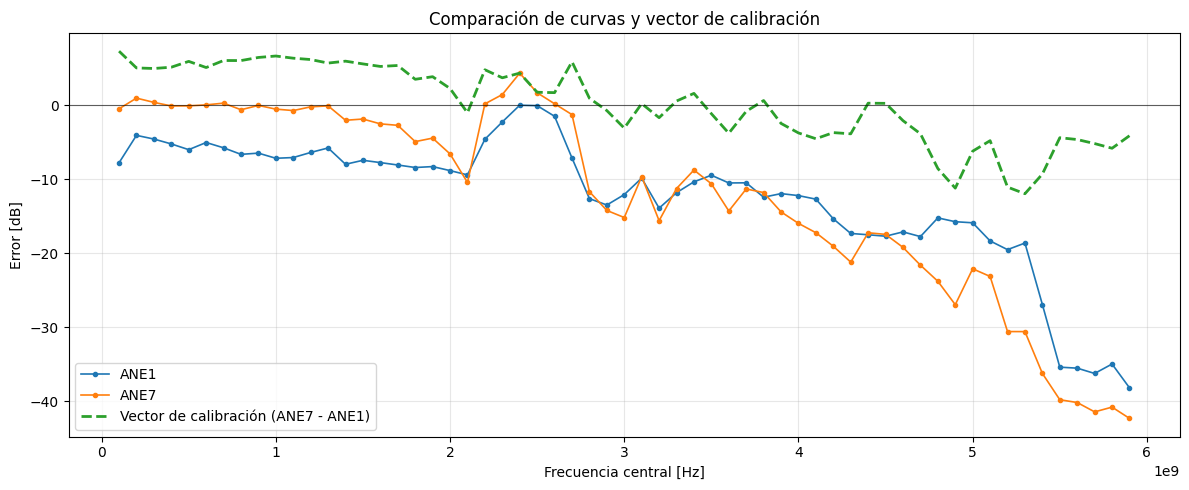

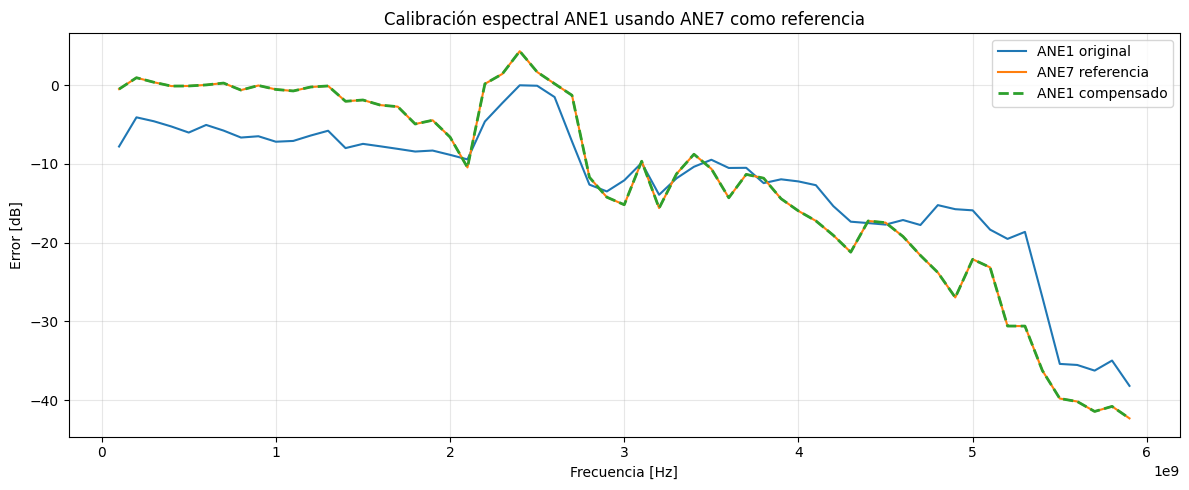


Archivo guardado: calibracion_ANE1_vs_ANE7.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# CONFIG
# =========================================================
FILE_1 = "resumen_potencia_error1.csv"   # sensor a corregir
FILE_7 = "resumen_potencia_error7.csv"   # referencia buena

COL_X = "Frecuencia_central_Hz"
COL_Y = "Error_dB"

# =========================================================
# LECTURA ROBUSTA
# =========================================================
def read_csv_robust(path):
    for enc in ("utf-8", "utf-8-sig", "latin1"):
        for sep in (",", ";", "\t"):
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep)
                if {COL_X, COL_Y}.issubset(df.columns):
                    return df
            except Exception:
                pass
    return pd.read_csv(path, sep=None, engine="python")

def load_clean(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"No existe el archivo: {path}")

    df = read_csv_robust(path).copy()

    if COL_X not in df.columns or COL_Y not in df.columns:
        raise ValueError(f"El archivo {path} debe contener {COL_X} y {COL_Y}")

    df[COL_X] = pd.to_numeric(df[COL_X], errors="coerce")
    df[COL_Y] = pd.to_numeric(df[COL_Y], errors="coerce")

    df = df.dropna(subset=[COL_X, COL_Y]).sort_values(COL_X)
    df = df.groupby(COL_X, as_index=False)[COL_Y].mean()
    return df

# =========================================================
# CARGA
# =========================================================
df1 = load_clean(FILE_1)
df7 = load_clean(FILE_7)

x1 = df1[COL_X].to_numpy()
y1 = df1[COL_Y].to_numpy()

x7 = df7[COL_X].to_numpy()
y7 = df7[COL_Y].to_numpy()

# =========================================================
# ALINEACIÓN EN RANGO COMÚN
# Usamos la malla del sensor 1
# =========================================================
xmin = max(x1.min(), x7.min())
xmax = min(x1.max(), x7.max())

mask = (x1 >= xmin) & (x1 <= xmax)

x_common = x1[mask]
y1_common = y1[mask]

# Interpolamos la referencia ANE7 en la malla de ANE1
y7_interp = np.interp(x_common, x7, y7)

# =========================================================
# VECTOR DE CALIBRACIÓN
# Queremos: y1_comp = y1 + vcal ≈ y7
# Entonces: vcal = y7 - y1
# =========================================================
vcal = y7_interp - y1_common

# Compensación
y1_comp = y1_common + vcal

# =========================================================
# MÉTRICAS
# =========================================================
mse_before = np.mean((y1_common - y7_interp)**2)
mse_after  = np.mean((y1_comp   - y7_interp)**2)

mae_before = np.mean(np.abs(y1_common - y7_interp))
mae_after  = np.mean(np.abs(y1_comp   - y7_interp))

print("=== Métricas ===")
print(f"MSE antes : {mse_before:.6f}")
print(f"MSE después: {mse_after:.6f}")
print(f"MAE antes : {mae_before:.6f}")
print(f"MAE después: {mae_after:.6f}")

# =========================================================
# PLOT 1: COMPARACIÓN DE CURVAS + DIFERENCIA
# =========================================================
plt.figure(figsize=(12,5))
plt.plot(x1, y1, label="ANE1", marker="o", markersize=3, linewidth=1.2)
plt.plot(x7, y7, label="ANE7", marker="o", markersize=3, linewidth=1.2)
plt.plot(x_common, vcal, label="Vector de calibración (ANE7 - ANE1)", linestyle="--", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)
plt.xlabel("Frecuencia central [Hz]")
plt.ylabel("Error [dB]")
plt.title("Comparación de curvas y vector de calibración")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: CALIBRACIÓN ESPECTRAL
# =========================================================
plt.figure(figsize=(12,5))
plt.plot(x_common, y1_common, label="ANE1 original", linewidth=1.5)
plt.plot(x_common, y7_interp, label="ANE7 referencia", linewidth=1.5)
plt.plot(x_common, y1_comp, label="ANE1 compensado", linewidth=2, linestyle="--")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Error [dB]")
plt.title("Calibración espectral ANE1 usando ANE7 como referencia")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# GUARDAR RESULTADOS
# =========================================================
out = pd.DataFrame({
    "Frecuencia_central_Hz": x_common,
    "ANE1_original_dB": y1_common,
    "ANE7_referencia_dB": y7_interp,
    "Vector_calibracion_dB": vcal,
    "ANE1_compensado_dB": y1_comp
})
out.to_csv("calibracion_ANE1_vs_ANE7.csv", index=False)
print("\nArchivo guardado: calibracion_ANE1_vs_ANE7.csv")

## Calibración espectral de ANE1 usando ANE7 como referencia

Sea $P_1(f)$ la curva del sensor ANE1 y $P_7(f)$ la curva del sensor ANE7, tomada como referencia.

El vector de calibración se define como:

$$
v_{\text{cal}}(f)=P_7(f)-P_1(f)
$$

Luego, la curva compensada de ANE1 se obtiene sumando ese vector de calibración:

$$
P_{1,\text{comp}}(f)=P_1(f)+v_{\text{cal}}(f)
$$

De esta manera, la respuesta espectral del sensor 1 se ajusta para parecerse lo más posible a la del sensor 7.